### WS 2020/21 <span style="float: right;">GET Lab<br />Paderborn University</span><br />
## <center>Digital Image Processing I<br /><br />Task Sheet 3</center>
---

### Overview

The objective of this exercise is to study spatial frequencies and image sampling. The first step for this is to create periodic patterns with known frequencies. One way to describe and generate such patterns is given by the wavenumber vector $\vec{\textbf{k}} = (k_x, k_y)^\text{T}$ (see lecture notes). The following figure illustrates the method:

<img src="images/wavenumber-vector.png" width="350px" />

The distance between two maxima is the wavelength $\lambda$, which is inversely proportional to the spatial frequency (the smaller $\lambda$, the larger the spatial frequency). The vector $\vec{\textbf{k}}$ is normal to the lines of constant gray values and describes the orientation of the periodic pattern. The length of this vector is set to:

$$|\vec{\textbf{k}}| = \dfrac{1}{\lambda}$$

By this means, the wavenumber vector $\vec{\textbf{k}}$ describes both the direction *and* the wavelength of the pattern. The components $k_x$ and $k_y$ directly describe the number of wavelengths per pixel in the corresponding direction (therefore, the values should be less than 1 for a reasonable implementation). The pattern can then be described as follows:

$$f(x,y) = a + a \cos(2\pi (k_x x + k_y y) - \Phi)$$

In this equation, $a$ is the amplitude of the periodic term *and* an offset (required because the cosine has a range of $\pm 1$ and we only want positive gray values here). The shift $\Delta x$ of the first maximum line from the coordinate origin (top left) is best described as a phase angle $\Phi = 2\pi \, \Delta x / \lambda$ so that we can directly choose $\Phi \in [0, 2\pi]$.

To comply with the sampling theorem, the sampling interval $r = \{1, 2, 3, \dots\}$ should be:

$$r \leq \dfrac{1}{2}\lambda$$

#### Plotting Images in Original Size

In the last exercise, a function has been provided to plot images in their original size. The function can be used here but images can only be displayed below each other. Instead of using complex <a href="https://matplotlib.org/3.3.2/api/_as_gen/matplotlib.pyplot.subplot.html">`subplot` ↗</a> commands to align images side by side, the results can be saved as PNG images and displayed using some HTML in a *Markdown* cell:

```
<img src="output/01.png"> <img src="output/03.png"><br />
<img src="output/02.png"> <img src="output/04.png">
```

To reload the images directly and not from the cache, just change and switch back the cell type (keyboard shortcut `m` for *Markdown* and `y` for *Code*).

---

In [3]:
import cv2
import numpy as np
from matplotlib import pyplot as plt

dpi = plt.rcParams['figure.dpi']

# plot grayscale image in original size
def plot_img_orig(img):
    rows, cols = img.shape # image size
    fig = plt.figure(figsize = (cols/dpi, rows/dpi))
    fig.add_axes([0, 0, 1, 1])
    plt.axis('off')
    plt.imshow(img, cmap='gray', vmin=0, vmax=255)
    plt.show()

#### <span style="color: RoyalBlue; font-weight: bold;">Task 3.1</span> Creating Periodic Patterns

Implement the following tasks:
1. Write a function to create an image with a periodic pattern using the wavenumber vector.
2. Create different periodic patterns with different parameters to test the function.
3. Create an image with 300 $\times$ 300 pixels and a periodic pattern with the following parameters:<br />
$\vec{\textbf{k}}_1 = (0.2, 0.2)^\text{T}$, $a_1 = 127.5$, $\Phi_1 = 0$
4. Create an image with 300 $\times$ 300 pixels and a periodic pattern with the following parameters:<br />
$\vec{\textbf{k}}_2 = (0.01, 0.05)^\text{T}$, $a_2 = 127.5$, $\Phi_2 = 0$

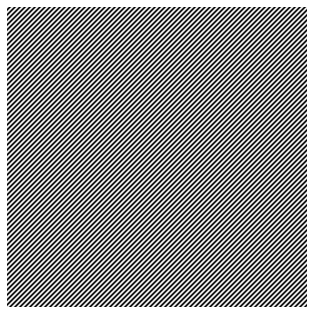

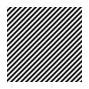

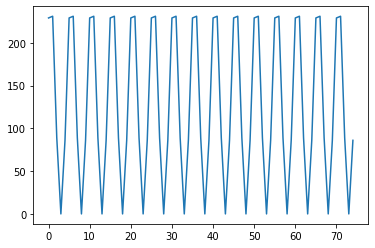

In [18]:
# write your code here

# create a periodic pattern using the wavenumber vector
def create_periodic_pattern(rows, cols, a, kx, ky, phi=0):
    # create black grayscale image
    img = np.zeros(shape=[rows, cols], dtype=np.uint8)
    for row in range(rows):
        for col in range(cols):
            img[row, col] = a + a*np.sin(2*np.pi*(kx*row + ky*col) - phi)

    return img # final image

img1 = create_periodic_pattern(300,300,127.5,0.2,0.2, 180)
plot_img_orig(img1)
# write your code here

# sample image with regular sampling interval r
def sample_image(img, r):
    rows, cols = img.shape # image size
    # create a new black image for the result
    img_s = np.zeros(shape=[int(rows/r), int(cols/r)], dtype=np.uint8)

    rows, cols = img_s.shape
    for row in range(rows):
        for col in range(cols):
            img_s[row, col] = img[r*row, r*col]

    return img_s # sampled image

    img_1_s = sample_image(img1, 4)
img_1_s = sample_image(img1, 4)
plot_img_orig(img_1_s)
img_1_s[0]
plt.plot(img_1_s[0])

In [19]:
img_1_s[0]

array([229, 231,  89,   0,  86, 229, 231,  89,   0,  86, 229, 231,  89,
         0,  86, 229, 231,  89,   0,  86, 229, 231,  89,   0,  86, 229,
       231,  89,   0,  86, 229, 231,  89,   0,  86, 229, 231,  89,   0,
        86, 229, 231,  89,   0,  86, 229, 231,  89,   0,  86, 229, 231,
        89,   0,  86, 229, 231,  89,   0,  86, 229, 231,  89,   0,  86,
       229, 231,  89,   0,  86, 229, 231,  89,   0,  86], dtype=uint8)

In [20]:
1/5

0.2

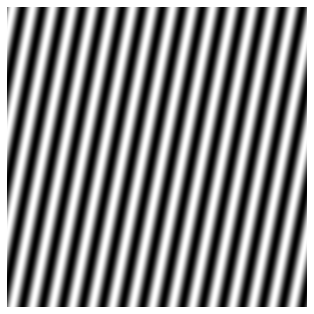

In [21]:
img2 = create_periodic_pattern(300,300,127.5,0.01,0.05)
plot_img_orig(img2)

#### <span style="color: RoyalBlue; font-weight: bold;">Task 3.2</span> Image Sampling

Implement / solve the following tasks:
1. Write a function to sample an image with a regular sampling interval $r$.
2. Determine the range of $r$ to comply with the sampling theorem for two images from the previous task.
3. Sample the two images from the previous task using $r=4$.
4. Plot and analyze the results. The OpenCV function <a href="https://docs.opencv.org/4.2.0/da/d54/group__imgproc__transform.html#ga47a974309e9102f5f08231edc7e7529d">`resize` ↗</a> can be used to resize the images for comparison. 
5. Test different sampling intervals and the influence of the amplitude and phase of the periodic pattern on the sampling.

In [22]:
# write your code here

# sample image with regular sampling interval r
def sample_image(img, r):
    rows, cols = img.shape # image size
    # create a new black image for the result
    img_s = np.zeros(shape=[int(rows/r), int(cols/r)], dtype=np.uint8)

    rows, cols = img_s.shape
    for row in range(rows):
        for col in range(cols):
            img_s[row, col] = img[r*row, r*col]

    return img_s # sampled image

In [23]:
print(1/np.sqrt(0.1**2 + 0.1**2)/2)
print(1/np.sqrt(0.01**2 + 0.05**2)/2)

3.535533905932737
9.8058067569092


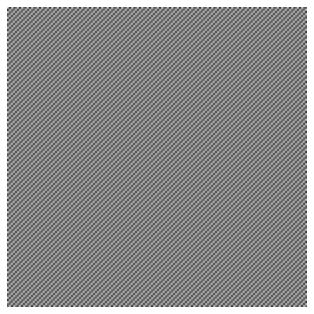

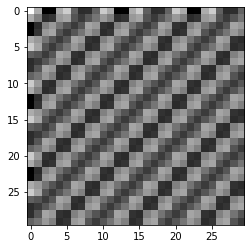

In [45]:
#r >= 1/2 * lambda
#r >= 1/2 * 1/sqrt(kx**2 + ky**2)
#r >= 1/2 * 

img_1_s = sample_image(img1, 2)
img_2_s = sample_image(img2, 4)

img_1_s = cv2.resize(img_1_s, (300, 300))
#img_2_s = cv2.resize(img_2_s, (300, 300))

plot_img_orig(img_1_s)
#plot_img_orig(img_2_s)
plt.imshow(img_1_s[0:30, 0:30], cmap='gray')

In [30]:
img_1_s[1][:8]

array([230, 175, 101,  36,  51, 130, 196, 219], dtype=uint8)

#### <span style="color: RoyalBlue; font-weight: bold;">Task 3.3</span> Creating Patterns with Variable Frequency

To create periodic patterns with variable frequency, the function from above can be modified. For example, the linear term in the cosine can be replaced by a quadratric term as follows:

$$f(x,y) = a + a \cos(2\pi (k_x x^2 + k_y y^2) - \Phi)$$

As the equation of a circle with the radius $r$ in the coordinate origin is given by $x^2 + y^2 = r^2$, this should lead to circular patterns.

Implement the following tasks:
1. Write a function to create an image with a pattern using the modified function.
2. Create images with 300 $\times$ 300 pixels and $\vec{\textbf{k}}_1 = (0.01, 0.01)^\text{T}$, $\vec{\textbf{k}}_2 = (0.001, 0.001)^\text{T}$, $\vec{\textbf{k}}_3 = (0.0001, 0.0001)^\text{T}$ and $a_i=127.5$, $\Phi_i=0$ for all patterns.
3. Plot the results.

In [29]:
# write your code here

# create a periodic pattern using the wavenumber vector
def create_periodic_pattern2(rows, cols, a, kx, ky, phi=0):
    # create black grayscale image
    img = np.zeros(shape=[rows, cols], dtype=np.uint8)
    
    for row in range(rows):
        for col in range(cols):
            img[row, col] = a + a * np.cos(2*np.pi*(kx * row**2 + ky * col**2) - phi)
    # ...

    return img # final image

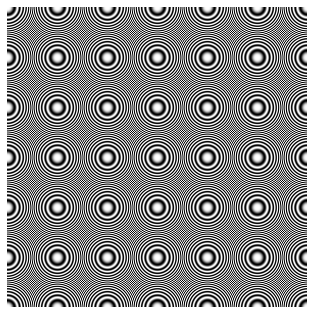

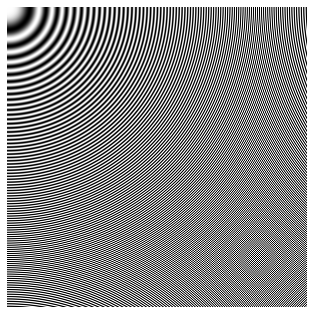

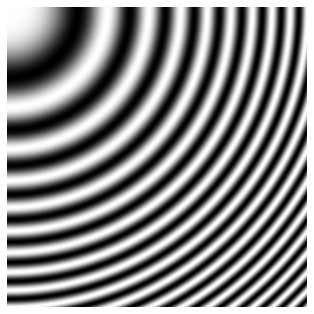

In [32]:
img1 = create_periodic_pattern2(300, 300, 127.5, 0.01, 0.01)
img2 = create_periodic_pattern2(300, 300, 127.5, 0.001, 0.001)
img3 = create_periodic_pattern2(300, 300, 127.5, 0.0001, 0.0001)
plot_img_orig(img1)
plot_img_orig(img2)
plot_img_orig(img3)


#### <span style="color: RoyalBlue; font-weight: bold;">Task 3.4</span> Moiré Effect

Implement the following tasks:
1. Sample the images from the previous task using different values for $r$ (e.g., 4 or 10).
2. Plot and analyze the results.

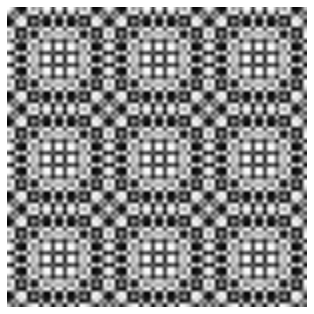

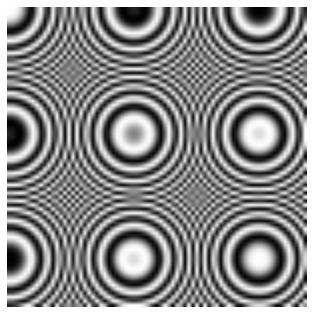

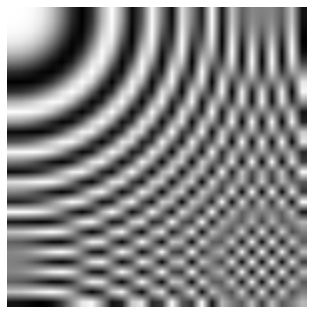

In [34]:
# write your code here
img_1_s = sample_image(img1, 4)
img_2_s = sample_image(img2, 4)
img_3_s = sample_image(img3, 10)

img_1_s = cv2.resize(img_1_s, (300, 300))
img_2_s = cv2.resize(img_2_s, (300, 300))
img_3_s = cv2.resize(img_3_s, (300, 300))

plot_img_orig(img_1_s)
plot_img_orig(img_2_s)
plot_img_orig(img_3_s)